# Scale Raw Gamma Matrix

After running `sample_ddp.py ODE --analyze-spectrum`, a **raw** gamma matrix is saved inside the sample folder.
This notebook applies per-frequency-bin min-max normalisation to produce the **scaled** matrix that CNS actually uses.

**Naming convention:**
- Raw  (from `--analyze-spectrum`): `gamma_matrix_<N>steps_ODE[_cfg_<scale>].pt`
- Scaled (used by CNS):             `gamma_matrix_scaled[_cfg_<scale>][_<N>steps].pt`

In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np
import os

## Configuration — edit these two lines only

In [2]:
NUM_STEPS = 250     # number of ODE sampling steps used when building the matrix
CFG_SCALE = None    # float (e.g. 1.5) or None for the unguided (cfg=1.0) matrix

## Load raw matrix

In [ ]:
cfg_suffix = f"_cfg_{CFG_SCALE}" if CFG_SCALE is not None else ""
steps_suffix = f"_{NUM_STEPS}steps" if NUM_STEPS != 250 else ""

raw_path = f"gamma_matrix/gamma_matrix_{NUM_STEPS}steps_ODE{cfg_suffix}.pt"
assert os.path.exists(raw_path), f"Raw matrix not found: {raw_path}"

gamma = torch.load(raw_path, map_location="cpu")
print(f"Loaded: {raw_path}")
print(f"Shape:  {gamma.shape}  (num_steps × num_freq_bins)")
print(f"Range:  [{gamma.min():.4f}, {gamma.max():.4f}]")

Loaded: gamma_matrix_check/gamma_matrix_250steps_ODE.pt
Shape:  torch.Size([250, 32])  (num_steps × num_freq_bins)
Range:  [0.0091, 1.0000]


## Scale — per-bin min-max normalisation to [0, 1]

In [ ]:
col_min = gamma.min(dim=0, keepdim=True)[0]
col_max = gamma.max(dim=0, keepdim=True)[0]
scaled = (gamma - col_min) / (col_max - col_min + 1e-8)

print(f"Scaled range: [{scaled.min():.4f}, {scaled.max():.4f}]")

out_path = f"gamma_matrix/gamma_matrix_scaled{cfg_suffix}{steps_suffix}.pt"
torch.save(scaled, out_path)
print(f"Saved:  {out_path}")

Scaled range: [0.0000, 1.0000]
Saved:  gamma_matrix_check/gamma_matrix_scaled.pt


## Visualise raw vs scaled

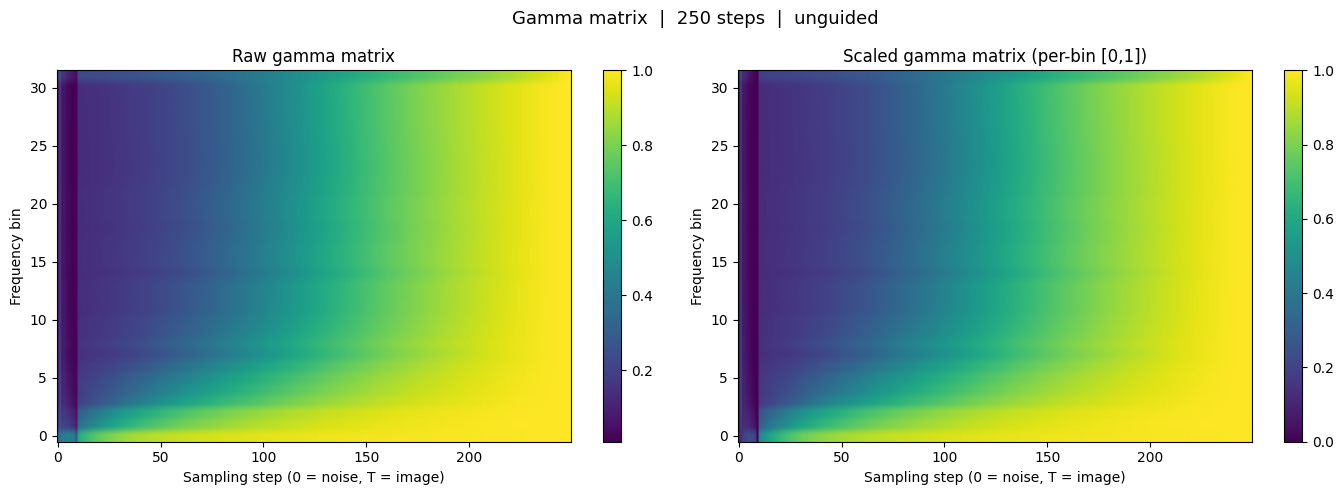

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, mat, title in zip(
    axes,
    [gamma.numpy(), scaled.numpy()],
    ["Raw gamma matrix", "Scaled gamma matrix (per-bin [0,1])"],
):
    im = ax.imshow(mat.T, origin="lower", aspect="auto", cmap="viridis")
    ax.set_title(title)
    ax.set_xlabel("Sampling step (0 = noise, T = image)")
    ax.set_ylabel("Frequency bin")
    fig.colorbar(im, ax=ax)

plt.suptitle(
    f"Gamma matrix  |  {NUM_STEPS} steps  |  "
    + (f"cfg={CFG_SCALE}" if CFG_SCALE else "unguided"),
    fontsize=13,
)
plt.tight_layout()
plt.show()

## Per-bin value range (sanity check)

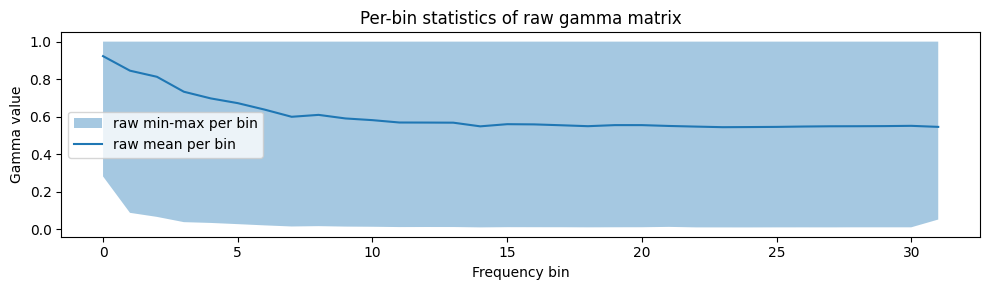

In [7]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.fill_between(range(gamma.shape[1]),
                gamma.min(dim=0)[0].numpy(),
                gamma.max(dim=0)[0].numpy(),
                alpha=0.4, label="raw min-max per bin")
ax.plot(gamma.mean(dim=0).numpy(), label="raw mean per bin")
ax.set_xlabel("Frequency bin")
ax.set_ylabel("Gamma value")
ax.set_title("Per-bin statistics of raw gamma matrix")
ax.legend()
plt.tight_layout()
plt.show()